# Email Spam Detection using Naive Bayes

Classify emails/messages as **ham (legitimate)** or **spam** using:

- TF-IDF text vectorization
- Multinomial Naive Bayes
- Train/test evaluation
- Sample message predictions


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

os.makedirs("outputs", exist_ok=True)


In [2]:
df = pd.read_csv("data/spam_ham_dataset.csv")

print("Shape:", df.shape)
display(df.head())
print("\nClass counts:")
display(df["label"].value_counts())


Shape: (1200, 2)


,label,message
0,spam,Congratulations! You have won a $500 cash priz...
1,ham,Don't forget your train ticket for tomorrow.
2,ham,Your appointment is confirmed for Tuesday at 2...
3,spam,You have been chosen for a limited-time cash r...
4,spam,FREE entry! Text WIN to 8000 for a chance to win.



Class counts:


label
spam    600
ham     600
Name: count, dtype: int64

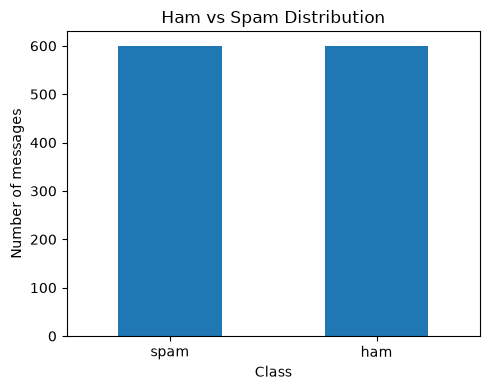

In [3]:
plt.figure(figsize=(5, 4))
df["label"].value_counts().plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Number of messages")
plt.title("Ham vs Spam Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("outputs/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["message"],
    df["label"],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2))),
    ("naive_bayes", MultinomialNB())
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, pos_label="spam"),
    "Recall": recall_score(y_test, y_pred, pos_label="spam"),
    "F1-Score": f1_score(y_test, y_pred, pos_label="spam")
}

display(pd.DataFrame([metrics]).round(3))


,Accuracy,Precision,Recall,F1-Score
0,1.0,1.0,1.0,1.0


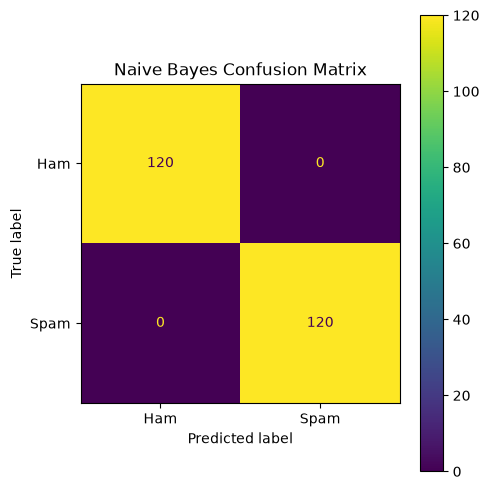

In [5]:
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])
disp = ConfusionMatrixDisplay(cm, display_labels=["Ham", "Spam"])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, values_format="d")
ax.set_title("Naive Bayes Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
sample_messages = [
    "Congratulations! You won a free cash prize. Claim your reward now.",
    "Can you send me the project notes after class?",
    "URGENT! Click here to verify your account and receive your bonus.",
    "Let's meet for lunch tomorrow at 1 PM."
]

sample_predictions = model.predict(sample_messages)
sample_probabilities = model.predict_proba(sample_messages)

for message, prediction, probability in zip(sample_messages, sample_predictions, sample_probabilities):
    print(f"Message: {message}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {probability.max():.2%}")
    print("-" * 70)


Message: Congratulations! You won a free cash prize. Claim your reward now.
Prediction: spam
Confidence: 99.95%
----------------------------------------------------------------------
Message: Can you send me the project notes after class?
Prediction: ham
Confidence: 99.36%
----------------------------------------------------------------------
Message: URGENT! Click here to verify your account and receive your bonus.
Prediction: spam
Confidence: 99.79%
----------------------------------------------------------------------
Message: Let's meet for lunch tomorrow at 1 PM.
Prediction: ham
Confidence: 99.51%
----------------------------------------------------------------------


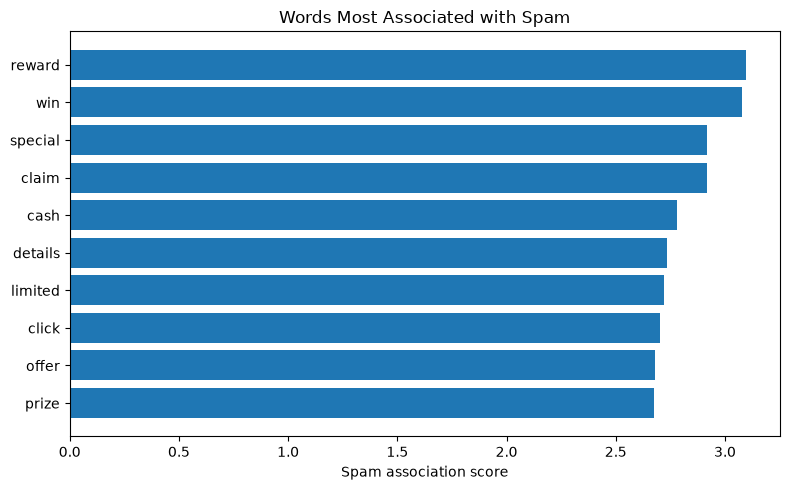

In [7]:
# Inspect the most influential words in the trained Naive Bayes model.
vectorizer = model.named_steps["tfidf"]
classifier = model.named_steps["naive_bayes"]

feature_names = vectorizer.get_feature_names_out()
spam_log_prob = classifier.feature_log_prob_[list(classifier.classes_).index("spam")]
ham_log_prob = classifier.feature_log_prob_[list(classifier.classes_).index("ham")]

word_scores = spam_log_prob - ham_log_prob
top_spam = np.argsort(word_scores)[-10:][::-1]

plt.figure(figsize=(8, 5))
plt.barh(feature_names[top_spam][::-1], word_scores[top_spam][::-1])
plt.xlabel("Spam association score")
plt.title("Words Most Associated with Spam")
plt.tight_layout()
plt.savefig("outputs/top_spam_words.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusion

TF-IDF converts message text into numerical features, and Multinomial Naive Bayes learns which terms are associated with ham or spam. The final sample predictions demonstrate how the trained classifier can classify unseen messages.

This dataset is synthetic and intended for educational use.
